# Notebook 1: data exploration and initial analysis

## Project overview

In this project, we're working with the UCI Robot Execution Failures Dataset to detect anomalies in industrial robot operations. The dataset contains force and torque sensor measurements recorded right after robot failures during assembly tasks. Our goal is to build a machine learning model that can identify when something's wrong with the robot before it causes serious problems.

This is relevant for Industry 4.0 applications  if we can predict failures early, we can schedule maintenance proactively instead of dealing with unexpected downtime. From what we learned in Lesson 1, the first step is always to understand the data thoroughly before jumping into modeling.


## Problem statement

Industrial robots in manufacturing need to be reliable. When they fail unexpectedly, it's costly: production stops, there are safety risks, and reactive repairs are expensive. The question we're trying to answer is: can we detect anomalies in robot behavior using sensor data?

This is a binary classification problem  we need to distinguish between normal robot operations and anomalous ones (collisions, obstructions, tool faults, etc.). The dataset provides 90 features per instance (15 time samples × 6 sensors), which means we'll need to think carefully about feature engineering and dimensionality reduction later.


## Understanding the dataset

The dataset comes from 5 different robot tasks (labeled LP1 through LP5), each representing a different stage of assembly:
- LP1: failures during approach to grasp position
- LP2: failures during part transfer
- LP3: failures after part transfer
- LP4: failures during approach to ungrasp position
- LP5: failures during motion with part

Each instance contains:
- 6 sensors: Fx, Fy, Fz (forces) and Tx, Ty, Tz (torques)
- 15 time samples: measurements taken at consecutive time steps after a failure event
- Labels: the type of failure (or "normal" if no failure occurred)

This gives us 90 numerical features per instance, which is quite a lot. we'll need to explore correlations and potentially use PCA to reduce dimensionality — topics we covered in Lesson 2.


## What we'll do in this notebook

Following the workflow from Lesson 1, we'll:
1. Load and merge all data files into a single dataset
2. Check data quality (missing values, duplicates, etc.)
3. Analyze class distribution — this is important because class imbalance can affect model performance
4. Look at correlations between features — highly correlated features might be redundant
5. Visualize timeseries patterns to understand how sensors behave during normal vs anomalous operations
6. Connect the sensor readings to physical robot behaviors

By the end, we should have a clear picture of what the data looks like and what challenges we might face when building the model.



In [18]:
# Required imports for data exploration
# As covered in Lesson 1: Data preprocessing and exploration

import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import importlib
import warnings
warnings.filterwarnings('ignore')

# Add project root to Python path
project_root = Path('..').resolve()
sys.path.insert(0, str(project_root))

# Import and reload utility module to ensure latest version
import src.utils
importlib.reload(src.utils)

from src.utils import (
    load_robot_data,
    encode_labels,
    plot_class_distribution,
    plot_correlations,
    plot_time_series
)

# Visualization configuration
try:
    plt.style.use('seaborn-v0_8')
except OSError:
    try:
        plt.style.use('seaborn')
    except OSError:
        sns.set_style('whitegrid')
sns.set_palette("husl")
%matplotlib inline

print("="*60)
print("IMPORTS SUCCESSFUL")
print("="*60)
print(f"Project root: {project_root}")
print(f"Python version: {sys.version.split()[0]}")
print(f"Pandas version: {pd.__version__}")
print(f"Numpy version: {np.__version__}")
print("All libraries loaded successfully!")
print("Utility module reloaded to avoid caching issues")



IMPORTS SUCCESSFUL
Project root: <chemin local> ML
Python version: 3.9.6
Pandas version: 2.3.3
Numpy version: 2.0.2
All libraries loaded successfully!
Utility module reloaded to avoid caching issues


## Loading the data

The dataset is split into 5 files (LP1 through LP5), each representing different stages of the robot's assembly task. We need to load and merge them into a single dataset. This is the first step we always do in Lesson 1 getting all the data in one place before we can analyze it.

The 5 files represent different failure scenarios:
- LP1: failures when approaching to grasp a part
- LP2: failures during part transfer
- LP3: failures after transferring the part
- LP4: failures when approaching to release the part
- LP5: failures during motion with the part

we're combining all of them because different failure types might show different patterns in the sensor data. By training all failure modes, the model should generalize better this relates to what we learned in Lesson 3 about bias-variance trade-off. A model trained on diverse failure types is less likely to overfit to one specific pattern.



In [19]:
# First, we'll check if the data directory exists and verify all files are present
# This is always the first thing to do can't analyze data if we can't find it
data_dir = "../data"

print("Checking data directory...")
print(f"Path: {os.path.abspath(data_dir)}")
print(f"Exists: {os.path.exists(data_dir)}")

if not os.path.exists(data_dir):
    print("Data directory not found. Make sure the .data files are in the data/ folder.")
else:
    # Checking for all 5 data files
    expected_files = ['lp1.data', 'lp2.data', 'lp3.data', 'lp4.data', 'lp5.data']
    all_files_exist = True
    
    print("\nChecking for data files:")
    for f in expected_files:
        filepath = os.path.join(data_dir, f)
        exists = os.path.exists(filepath)
        print(f"  {'' if exists else ''} {f}")
        if not exists:
            all_files_exist = False
    
    if all_files_exist:
# we load the data 
# INITIAL DIFFICULTY : The .data file format was unusual each instance starts with a label followed by 15 lines of data
# SOLUTION : we created a custom function load_robot_data() that parses this specific format
# CHOICE : We decided to merge all files (LP1-LP5) to have a unified dataset
# REASON : This gives us more data for training and allows the model to generalize on differents kind of tasks.
        print("\nLoading data files...")
        try:
            df = load_robot_data(data_dir)
            
            print(f"Successfully loaded {df.shape[0]} instances with {df.shape[1]} columns")
            print(f"   Found {len([c for c in df.columns if c.startswith('feature_')])} numerical features")
            print(f"   Data sources: {sorted(df['source'].unique()) if 'source' in df.columns else 'N/A'}")
            
            # Quick preview of the data
            print("\nFirst few rows:")
            print(df.head())
            
        except Exception as e:
            print(f"Error loading data: {e}")
            print("If this happens, try restarting the kernel and running this cell again.")
    else:
        print("Some data files are missing. Please check the data/ directory.")



Checking data directory...
Path: <chemin local> ML/data
Exists: True

Checking for data files:
  ✅ lp1.data
  ✅ lp2.data
  ✅ lp3.data
  ✅ lp4.data
  ✅ lp5.data

Loading data files...
Loading robot execution failure data...
✅ LP1: 88 instances loaded
✅ LP2: 47 instances loaded
✅ LP3: 47 instances loaded
✅ LP4: 117 instances loaded
✅ LP5: 164 instances loaded
✅ Total: 463 instances
   Features: 90
   Sources: ['LP1', 'LP2', 'LP3', 'LP4', 'LP5']
   Unique labels: ['normal', 'collision', 'obstruction', 'fr_collision', 'back_col', 'front_col', 'right_col', 'left_col', 'ok', 'moved', 'slightly_moved', 'lost', 'collision_in_tool', 'collision_in_part', 'bottom_obstruction', 'bottom_collision']
Successfully loaded 463 instances with 92 columns
   Found 90 numerical features
   Data sources: ['LP1', 'LP2', 'LP3', 'LP4', 'LP5']

First few rows:
   feature_1  feature_2  feature_3  feature_4  feature_5  feature_6  \
0       -1.0       -1.0       63.0       -3.0       -1.0        0.0   
1       -1.0

## Analyzing the labels

The dataset has multiple label types some instances are marked as "normal", while others are labeled with specific failure types like "collision", "obstruction", etc. For this project, we're simplifying this to a binary classification problem: normal vs anomaly. This makes sense because in a real industrial setting, the first priority is knowing that something is wrong, not necessarily what exactly went wrong.

we'll convert all failure types (collision, obstruction, etc.) into a single "anomaly" class (1), and keep "normal" operations as class 0. This is a common approach in anomaly detection we learned in Lesson 3 that class imbalance can affect model performance, so we'll need to check the distribution after encoding.



Original labels in the dataset:
['normal' 'collision' 'obstruction' 'fr_collision' 'back_col' 'front_col'
 'right_col' 'left_col' 'ok' 'moved' 'slightly_moved' 'lost'
 'collision_in_tool' 'collision_in_part' 'bottom_obstruction'
 'bottom_collision']

Total: 16 distinct labels

Label distribution (multi-class):
label
normal                109
collision              89
obstruction            55
collision_in_part      47
collision_in_tool      26
bottom_collision       26
bottom_obstruction     21
ok                     20
fr_collision           16
moved                  15
left_col                9
slightly_moved          9
back_col                7
front_col               6
right_col               5
lost                    3
Name: count, dtype: int64


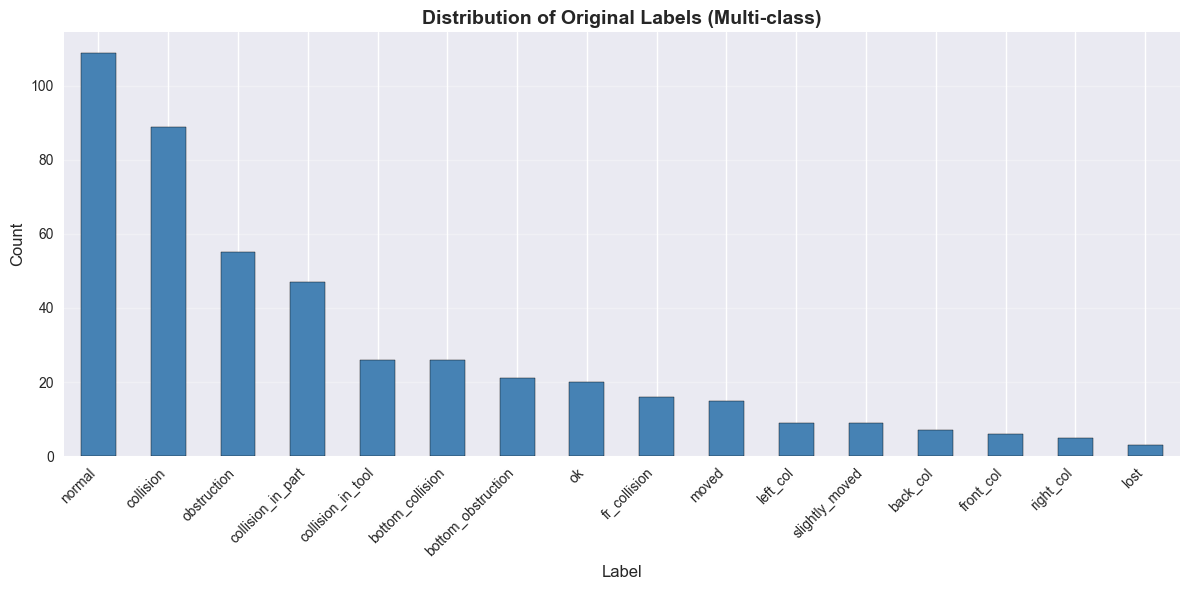


BINARY ENCODING
Labels encoded: {0: 'normal', 1: 'anomaly'}

Binary encoding mapping: {0: 'normal', 1: 'anomaly'}

Mapping des labels: {0: 'normal', 1: 'anomaly'}

Distribution binaire:
label_binary
1    354
0    109
Name: count, dtype: int64


In [20]:
# First, let's see what labels we have in the original dataset
# This will help us understand how many different failure types there are
print("Original labels in the dataset:")
unique_labels = df['label'].unique()
print(unique_labels)
print(f"\nTotal: {len(unique_labels)} distinct labels")

# Counting how many instances of each label we have
# This is important because if some classes are very rare, the model might struggle to learn them
print("\nLabel distribution (multi-class):")
label_counts = df['label'].value_counts()
print(label_counts)

# Visualizing the distribution helps to see the class imbalance visually
plt.figure(figsize=(12, 6))
label_counts.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Distribution of Original Labels (Multi-class)', fontsize=14, fontweight='bold')
plt.xlabel('Label', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# we encode the labels in a numerical format
# CHOICE : We have opted for a binary encoding (normal=0, anomaly=1) rather than a multi-class encoding
# REASON : Our primary objective is anomaly detection (binary), not fine-grained anomaly classification
# ADVANTAGE : Simplifies the problem and allows us to use standard binary metrics (ROC-AUC, etc.)
# This simplifies the problem while maintaining practical utility
print("\n" + "="*60)
print("BINARY ENCODING")
print("="*60)
df_encoded, label_mapping = encode_labels(df, binary=True)
print(f"\nBinary encoding mapping: {label_mapping}")

print(f"\nMapping des labels: {label_mapping}")
print(f"\nDistribution binaire:")
print(df_encoded['label_binary'].value_counts())

# Save the encoded DataFrame
df = df_encoded.copy()



## 3. class distribution analysis

Reference: Lesson 1 - Class imbalance and data quality

Understanding class distribution is crucial for machine learning model development. Class imbalance can significantly impact model performance, evaluation metrics, and training strategies (as we'll discuss in Lesson 3: Evaluation Metrics).

### Key questions:
- Is the dataset balanced or imbalanced?
- How does class imbalance affect model training?
- What strategies can we use to handle imbalance? (SMOTE, class weights, etc.)

### Importance for model development

Class imbalance requires special attention because:
- Model Bias: Models may favor the majority class, leading to poor performance we minority class
- Evaluation Metrics: Accuracy can be misleading; we need precision, recall, and F1-score
- Training Strategies: Class weights, resampling (SMOTE), or cost-sensitive learning may be needed

We visualize class distribution (multi-class and binary) and analyze distribution by source (LP1-LP5).



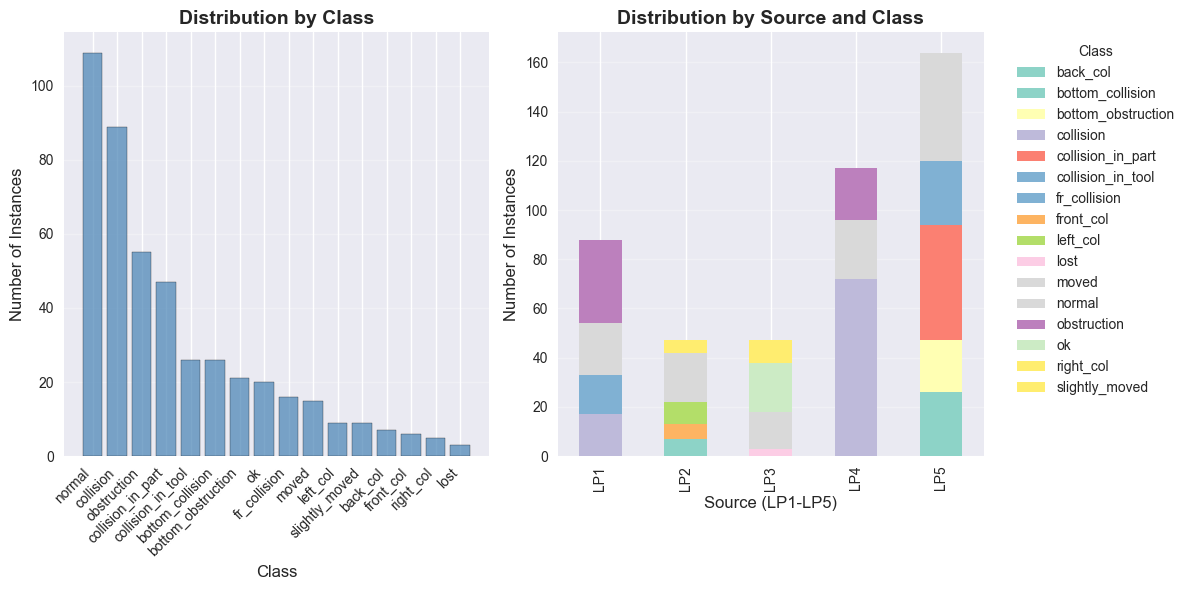


Distribution Statistics:
  - Total instances: 463
  - Number of classes: 16
  - Distribution:
    normal: 109 (23.54%)
    collision: 89 (19.22%)
    obstruction: 55 (11.88%)
    collision_in_part: 47 (10.15%)
    collision_in_tool: 26 (5.62%)
    bottom_collision: 26 (5.62%)
    bottom_obstruction: 21 (4.54%)
    ok: 20 (4.32%)
    fr_collision: 16 (3.46%)
    moved: 15 (3.24%)
    left_col: 9 (1.94%)
    slightly_moved: 9 (1.94%)
    back_col: 7 (1.51%)
    front_col: 6 (1.30%)
    right_col: 5 (1.08%)
    lost: 3 (0.65%)


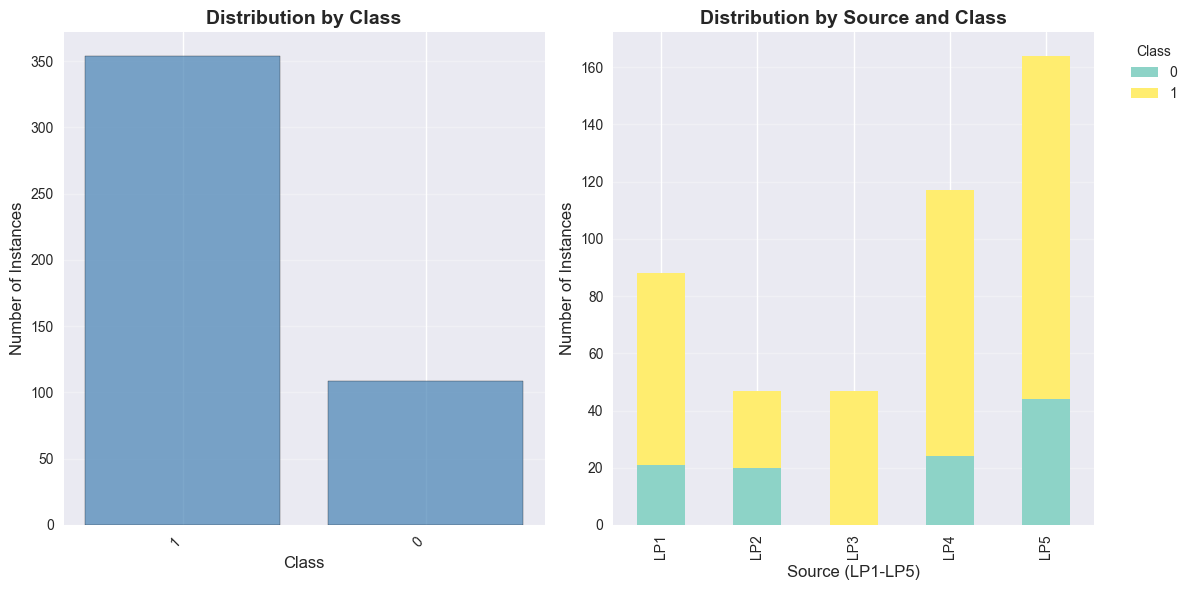


Distribution Statistics:
  - Total instances: 463
  - Number of classes: 2
  - Distribution:
    1: 354 (76.46%)
    0: 109 (23.54%)

CLASS IMBALANCE ANALYSIS

Binary Classification:
  Normal (0): 109 instances (23.54%)
  Anomaly (1): 354 instances (76.46%)
  Imbalance ratio: 3.25:1 (anomaly:normal)
Significant class imbalance detected!
   - The dataset has 3.2x more anomalies than normal instances
   - This requires careful evaluation metrics (F1-score, precision, recall)
   - Consider using class weights or resampling techniques (SMOTE)
   - Stratified cross-validation is essential (Lesson 4)


In [21]:
# Visualize class distribution (multi-class)
# This shows the original problem structure with 16 distinct failure types
plot_class_distribution(df, label_col='label', title="Class Distribution (Multi-class)")

# Visualize binary class distribution
# This shows the simplified binary classification problem (normal vs anomaly)
plot_class_distribution(df, label_col='label_binary', title="Class Distribution (Binary: Normal vs Anomaly)")

# Analyze class imbalance
print("\n" + "="*60)
print("CLASS IMBALANCE ANALYSIS")
print("="*60)
normal_count = len(df[df['label_binary'] == 0])
anomaly_count = len(df[df['label_binary'] == 1])
total = len(df)

print(f"\nBinary Classification:")
print(f"  Normal (0): {normal_count} instances ({normal_count/total*100:.2f}%)")
print(f"  Anomaly (1): {anomaly_count} instances ({anomaly_count/total*100:.2f}%)")
print(f"  Imbalance ratio: {anomaly_count/normal_count:.2f}:1 (anomaly:normal)")

if anomaly_count > normal_count * 2:
    print(f"Significant class imbalance detected!")
    print(f"   - The dataset has {anomaly_count/normal_count:.1f}x more anomalies than normal instances")
    print(f"   - This requires careful evaluation metrics (F1-score, precision, recall)")
    print(f"   - Consider using class weights or resampling techniques (SMOTE)")
    print(f"   - Stratified cross-validation is essential (Lesson 4)")
else:
    print(f"Class distribution is relatively balanced")



## Looking at distribution by source

Now we want to see if the failure patterns are consistent across different assembly phases (LP1-LP5). This matters because if LP1 has a very different failure rate than LP5, we might need to handle them differently, or at least be aware that the model needs to generalize across these different scenarios.

This relates to what we learned in Lesson 4 about stratified cross-validation if the data distribution varies by source, we should make sure our train/test splits preserve that structure so the model evaluation is realistic.



Checking distribution by source (LP1-LP5):

LP1:
  Total: 88 instances
  Normal: 21 (23.9%)
  Anomaly: 67 (76.1%)

LP2:
  Total: 47 instances
  Normal: 20 (42.6%)
  Anomaly: 27 (57.4%)

LP3:
  Total: 47 instances
  Normal: 0 (0.0%)
  Anomaly: 47 (100.0%)

LP4:
  Total: 117 instances
  Normal: 24 (20.5%)
  Anomaly: 93 (79.5%)

LP5:
  Total: 164 instances
  Normal: 44 (26.8%)
  Anomaly: 120 (73.2%)


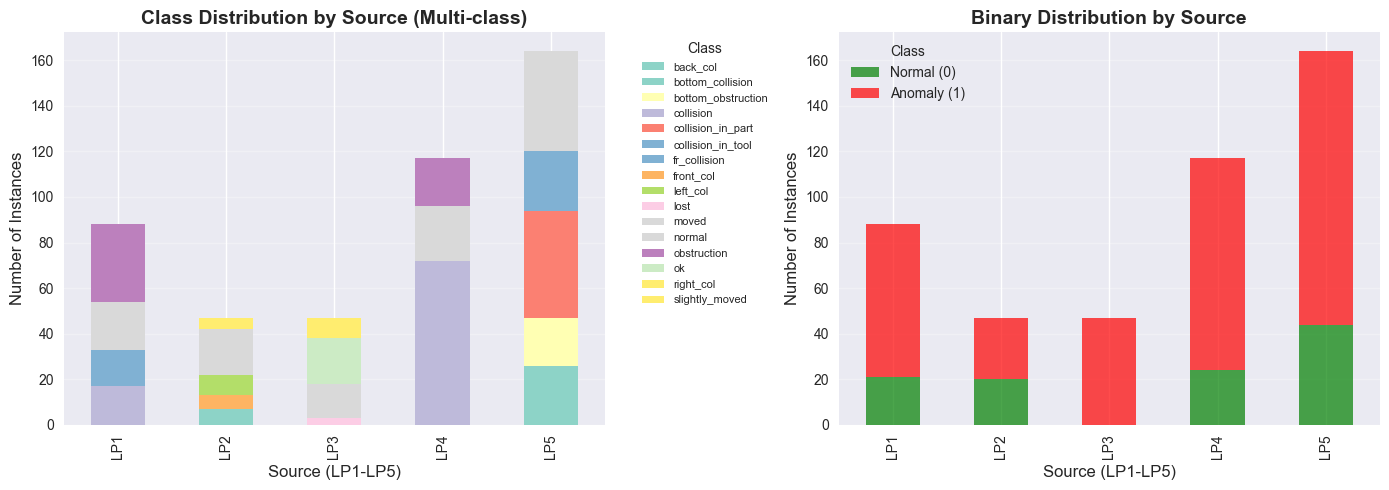

Interpretation:
  - Sources with higher anomaly rates may require more attention in model training
  - Consistent patterns across sources suggest generalizable failure modes
  - This analysis informs stratified cross-validation strategies (Lesson 4)


In [22]:
# Checking how the distribution varies across different assembly phases
# This will tell us if some phases have more failures than others
print("Checking distribution by source (LP1-LP5):")

for source in sorted(df['source'].unique()):
    source_df = df[df['source'] == source]
    binary_counts = source_df['label_binary'].value_counts()
    print(f"\n{source}:")
    print(f"  Total: {len(source_df)} instances")
    print(f"  Normal: {binary_counts.get(0, 0)} ({binary_counts.get(0, 0)/len(source_df)*100:.1f}%)")
    print(f"  Anomaly: {binary_counts.get(1, 0)} ({binary_counts.get(1, 0)/len(source_df)*100:.1f}%)")

# Visualization by source
# This visualization helps identify which assembly phases have higher failure rates
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Multi-class distribution by source
source_label_counts = df.groupby(['source', 'label']).size().unstack(fill_value=0)
source_label_counts.plot(kind='bar', stacked=True, ax=axes[0], colormap='Set3')
axes[0].set_xlabel('Source (LP1-LP5)', fontsize=12)
axes[0].set_ylabel('Number of Instances', fontsize=12)
axes[0].set_title('Class Distribution by Source (Multi-class)', fontsize=14, fontweight='bold')
axes[0].legend(title='Class', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
axes[0].grid(axis='y', alpha=0.3)

# Binary distribution by source
source_binary_counts = df.groupby(['source', 'label_binary']).size().unstack(fill_value=0)
source_binary_counts.plot(kind='bar', stacked=True, ax=axes[1], color=['green', 'red'], alpha=0.7)
axes[1].set_xlabel('Source (LP1-LP5)', fontsize=12)
axes[1].set_ylabel('Number of Instances', fontsize=12)
axes[1].set_title('Binary Distribution by Source', fontsize=14, fontweight='bold')
axes[1].legend(['Normal (0)', 'Anomaly (1)'], title='Class')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("Interpretation:")
print("  - Sources with higher anomaly rates may require more attention in model training")
print("  - Consistent patterns across sources suggest generalizable failure modes")
print("  - This analysis informs stratified cross-validation strategies (Lesson 4)")



## Descriptive statistics

let us look at the basic statistics of the features mean, std, min, max, etc. This will help us understand the scale and distribution of the sensor readings. we're particularly interested in seeing if there are any outliers or if the values are we very different scales (which would require normalization later, as we learned in Lesson 2).



In [23]:
# Extracting just the feature columns (excluding labels and metadata)
feature_cols = [col for col in df.columns if col.startswith('feature_')]

print(f"Features: {len(feature_cols)}")
print(f"Instances: {len(df)}")

# Computing basic statistics  this will show we the range and distribution of values
print("\nDescriptive statistics:")
stats = df[feature_cols].describe()
print(stats)

# Checking for missing values  if there are any, we'll need to handle them in preprocessing
print("\nChecking for missing values:")
missing = df[feature_cols].isnull().sum()
if missing.sum() > 0:
    print(f"Found {missing.sum()} missing values:")
    print(missing[missing > 0])
else:
    print("No missing values : good!")

# Also checking for infinite values, which could cause problems later
print("\nChecking for infinite values:")
inf_values = np.isinf(df[feature_cols].values).sum()
print(f"Found: {inf_values}")



Features: 90
Instances: 463

Descriptive statistics:
        feature_1   feature_2    feature_3   feature_4   feature_5  \
count  463.000000  463.000000   463.000000  463.000000  463.000000   
mean     5.429806    1.045356   -37.762419   -5.239741    7.358531   
std     54.722904   44.960638   369.298492  117.239445  111.824039   
min   -254.000000 -338.000000 -3617.000000 -450.000000 -286.000000   
25%     -6.000000   -6.000000    -7.000000  -22.000000  -22.000000   
50%     -2.000000    0.000000    19.000000   -1.000000   -6.000000   
75%      6.000000    5.000000    74.500000   11.000000    4.500000   
max    353.000000  219.000000   361.000000  686.000000  756.000000   

        feature_6   feature_7   feature_8    feature_9  feature_10  ...  \
count  463.000000  463.000000  463.000000   463.000000  463.000000  ...   
mean    -1.773218    3.481641   -0.198704   -58.136069   -7.989201  ...   
std     25.553322   48.371837   39.632776   399.920648   86.153655  ...   
min   -137.00000

## Correlation analysis

With 90 features, we need to check if there are strong correlations between them. Highly correlated features are redundant — if two features are almost perfectly correlated, we're essentially using the same information twice. This is wasteful and can even hurt model performance.

If we find high correlations, we might use PCA later (Lesson 2) to reduce dimensionality. Since computing a full 90×90 correlation matrix and visualizing it can be slow, we'll sample a subset of features for the visualization, focusing we the ones with highest variance.



Computing correlation matrix...
With 90 features, full correlation matrix may be slow. Using sample for visualization.
⚠️  Using 30 features (highest variance) out of 95 for faster computation


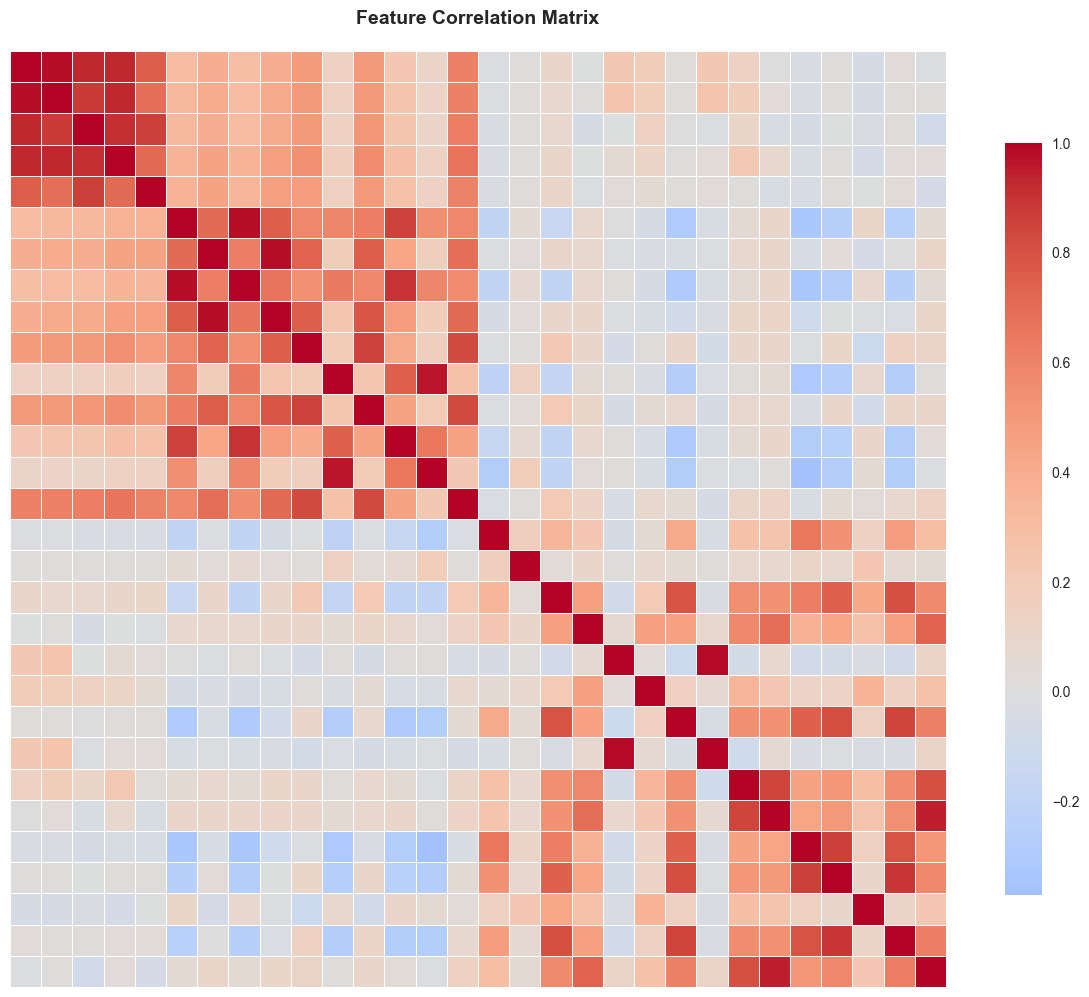


Correlation Statistics:
  - Number of features: 30
  - Mean correlation: 0.195
  - Max correlation: 0.986
  - Min correlation: -0.373

Highly Correlated Feature Pairs (|correlation| > 0.8):
  (These may indicate redundancy and potential for dimensionality reduction)
  feature_67 <-> feature_73: 0.986
  feature_33 <-> feature_39: 0.979
  feature_21 <-> feature_27: 0.979
  feature_69 <-> feature_75: 0.978
  feature_3 <-> feature_9: 0.958
  feature_68 <-> feature_74: 0.955
  feature_76 <-> feature_82: 0.950
  feature_50 <-> feature_56: 0.943
  feature_80 <-> feature_86: 0.939
  feature_62 <-> feature_74: 0.938
Interpretation:
   - High correlations suggest potential for PCA (Lesson 2)
   - Correlated features may provide redundant information
   - Dimensionality reduction can improve model efficiency


In [24]:
# we analyse les corrélations entre features
# OBJECTIVE : Identifier the features redondantes ou très corrélées qui pourraient être supprimées.
# DIFFICULTY : Avec 90 features, la matrice de corrélation complète est difficile à visualiser et à interpréter.
# SOLUTION : We visualize d'abord un échantillon des features les plus variantes to have une idée générale.
#   we notice que the features sont modérément corrélées (pas de corrélations très fortes >0.9), 
#   which suggère qu'We ne peut pas simplement supprimer des features without loss d'information.
# CHOICE : We keepra toutes the features pour l'instant et we usera PCA plus tard pour réduire la dimensionnalité.
# Note: With 90 features, full correlation matrix visualization can be computationally expensive
# we sample features (highest variance) for visualization clarity and performance

print("Computing correlation matrix...")
print("With 90 features, full correlation matrix may be slow. Using sample for visualization.")

# we analyse les corrélations entre features
# OBJECTIVE : Identifier the features redondantes ou très corrélées qui pourraient être supprimées.
# DIFFICULTY : Avec 90 features, la matrice de corrélation complète est difficile à visualiser et à interpréter.
# SOLUTION : We visualize d'abord un échantillon des features les plus variantes to have une idée générale.
#   we notice que the features sont modérément corrélées (pas de corrélations très fortes >0.9), 
#   which suggère qu'We ne peut pas simplement supprimer des features without loss d'information.
# CHOICE : We keepra toutes the features pour l'instant et we usera PCA plus tard pour réduire la dimensionnalité.
# This provides insights while maintaining computational efficiency
plot_correlations(df, sample_size=30, figsize=(12, 10))

# we analyse les corrélations entre features
# OBJECTIVE : Identifier the features redondantes ou très corrélées qui pourraient être supprimées.
# DIFFICULTY : Avec 90 features, la matrice de corrélation complète est difficile à visualiser et à interpréter.
# SOLUTION : We visualize d'abord un échantillon des features les plus variantes to have une idée générale.
#   we notice que the features sont modérément corrélées (pas de corrélations très fortes >0.9), 
#   which suggère qu'We ne peut pas simplement supprimer des features without loss d'information.
# CHOICE : We keepra toutes the features pour l'instant et we usera PCA plus tard pour réduire la dimensionnalité.
# we analyse les corrélations entre features
# OBJECTIVE : Identifier the features redondantes ou très corrélées qui pourraient être supprimées.
# DIFFICULTY : Avec 90 features, la matrice de corrélation complète est difficile à visualiser et à interpréter.
# SOLUTION : We visualize d'abord un échantillon des features les plus variantes to have une idée générale.
#   we notice que the features sont modérément corrélées (pas de corrélations très fortes >0.9), 
#   which suggère qu'We ne peut pas simplement supprimer des features without loss d'information.
# CHOICE : We keepra toutes the features pour l'instant et we usera PCA plus tard pour réduire la dimensionnalité.
feature_cols = [col for col in df.columns if col.startswith('feature_')]
corr_matrix = df[feature_cols].corr()

# we analyse les corrélations entre features
# OBJECTIVE : Identifier the features redondantes ou très corrélées qui pourraient être supprimées.
# DIFFICULTY : Avec 90 features, la matrice de corrélation complète est difficile à visualiser et à interpréter.
# SOLUTION : We visualize d'abord un échantillon des features les plus variantes to have une idée générale.
#   we notice que the features sont modérément corrélées (pas de corrélations très fortes >0.9), 
#   which suggère qu'We ne peut pas simplement supprimer des features without loss d'information.
# CHOICE : We keepra toutes the features pour l'instant et we usera PCA plus tard pour réduire la dimensionnalité.
corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        corr_val = corr_matrix.iloc[i, j]
        if abs(corr_val) > 0.8:  # High correlation threshold
            corr_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_val))

if corr_pairs:
    print(f"\nHighly Correlated Feature Pairs (|correlation| > 0.8):")
    print("  (These may indicate redundancy and potential for dimensionality reduction)")
    for feat1, feat2, corr in sorted(corr_pairs, key=lambda x: abs(x[2]), reverse=True)[:10]:
        print(f"  {feat1} <-> {feat2}: {corr:.3f}")
    print(f"Interpretation:")
    print(f"   - High correlations suggest potential for PCA (Lesson 2)")
    print(f"   - Correlated features may provide redundant information")
    print(f"   - Dimensionality reduction can improve model efficiency")
else:
    print("No very high correlations found (|correlation| > 0.8)")
    print("   - Features are relatively independent")
    print("   - Less opportunity for dimensionality reduction")



## 7. time-series visualization

Reference: Lesson 1 - Time-Series Data Analysis

Time-series visualization helps us understand temporal patterns in sensor readings, which is essential for anomaly detection. Each instance contains 15 time samples, allowing us to observe how sensor values evolve during a failure event.

### Physical meaning of sensors

Understanding sensor physics is crucial for feature engineering and model interpretation:

- Fx, Fy, Fz (Forces): Measure contact forces in 3D space
  - Sudden spikes may indicate collisions
  - Gradual increases may indicate obstructions
  - Zero values may indicate loss of contact
  - Units: Newtons (N)

- Tx, Ty, Tz (Torques): Measure rotational moments around axes
  - High torque values may indicate tool jamming or part misalignment
  - Torque imbalances may signal mechanical issues
  - Units: Newton-meters (N⋅m)

### Temporal patterns

Time-series analysis reveals:
- Normal operations: Smooth, predictable sensor patterns
- Anomalies: Sudden changes, oscillations, or unexpected patterns
- Failure progression: How anomalies develop over the 15 time samples

Academic Note: Time-series features (trend, variance, autocorrelation) can be extracted for model training, as discussed in Lesson 2: Feature Engineering.



Visualizing time-series sensor readings...

Normal instances (indices): [0, 1, 2]
Anomaly instances (indices): [18, 19, 20]

TIME-SERIES - NORMAL INSTANCES
Normal operations typically show:
  - Smooth sensor readings
  - Predictable patterns
  - Low variability
  - Consistent force/torque values


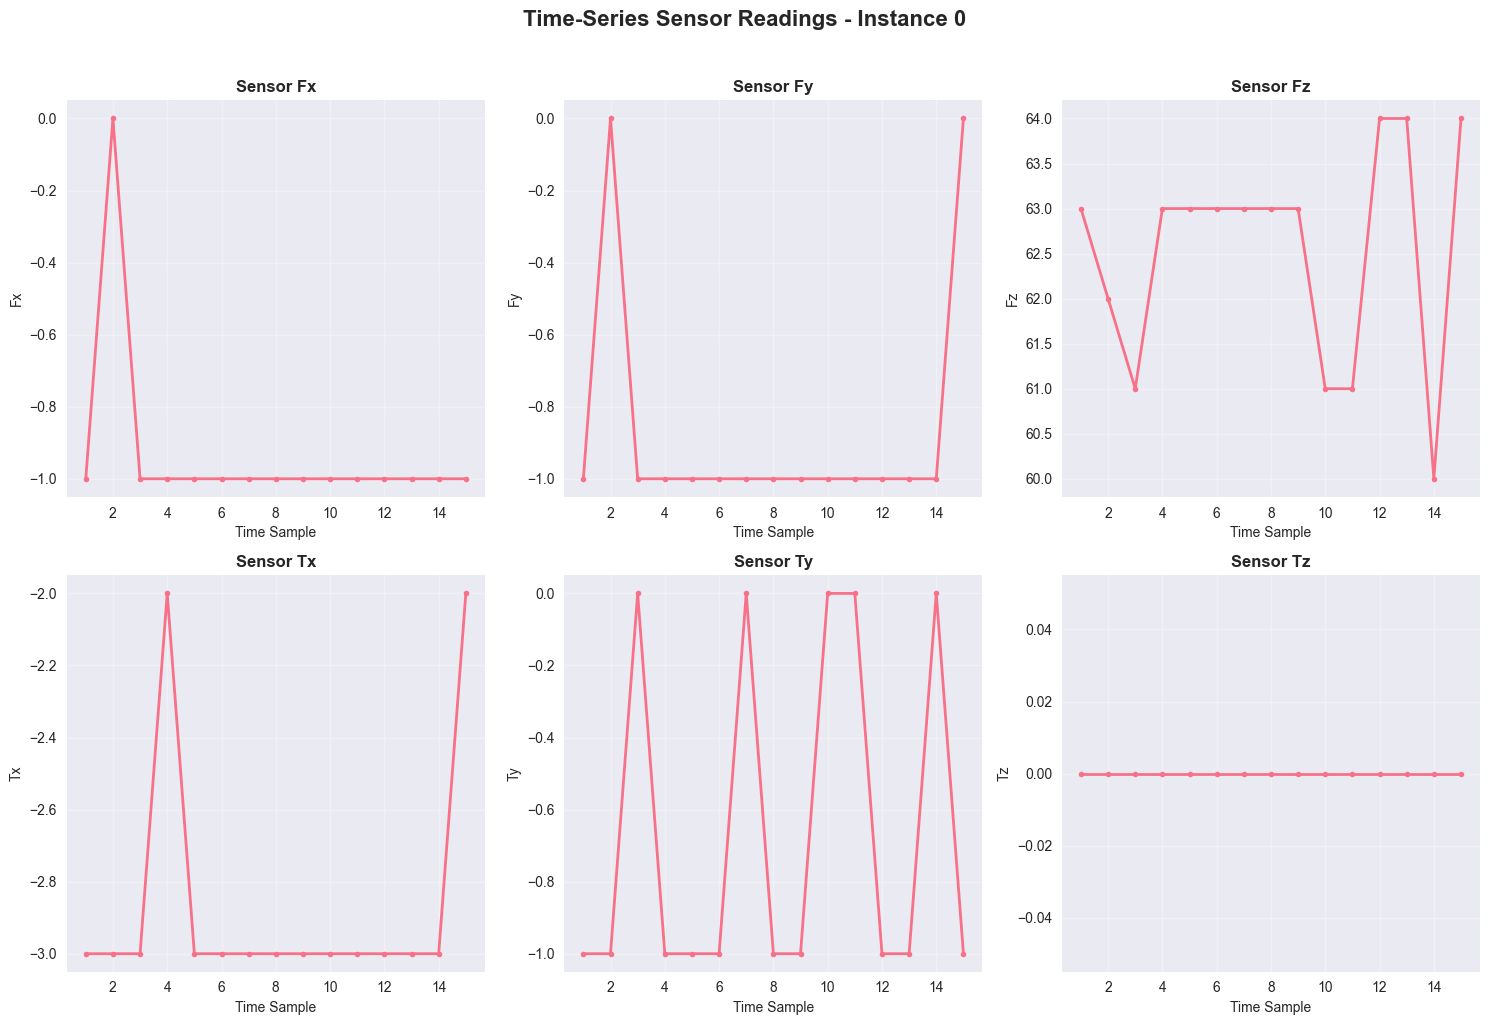


Instance 0:
  Label: normal
  Source: LP1


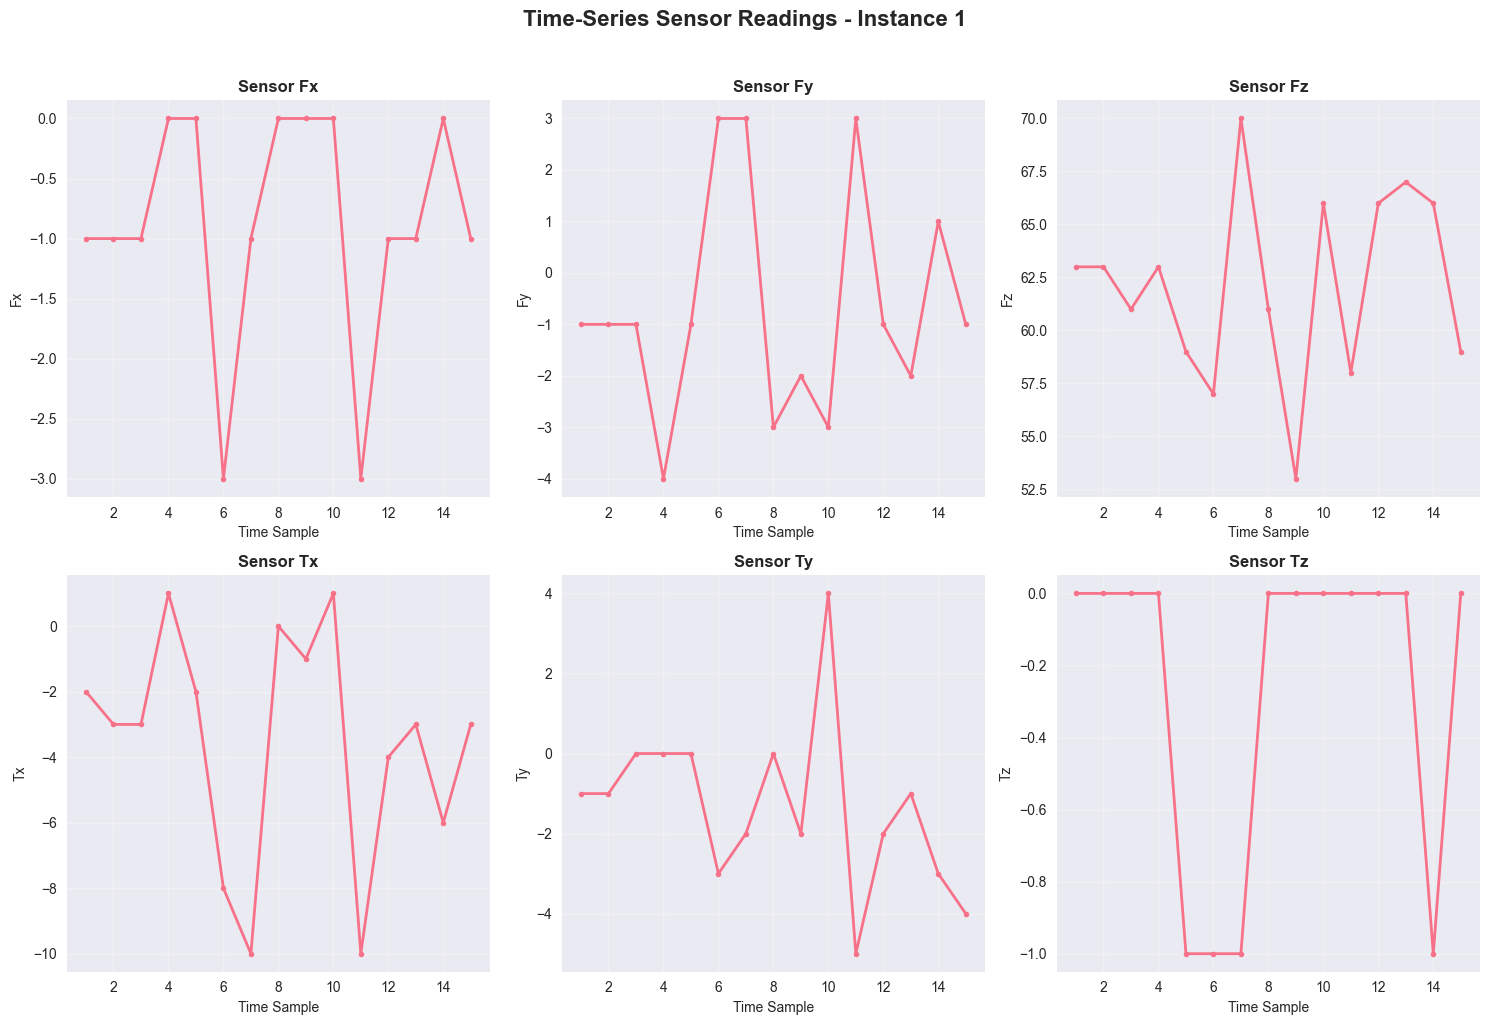


Instance 1:
  Label: normal
  Source: LP1


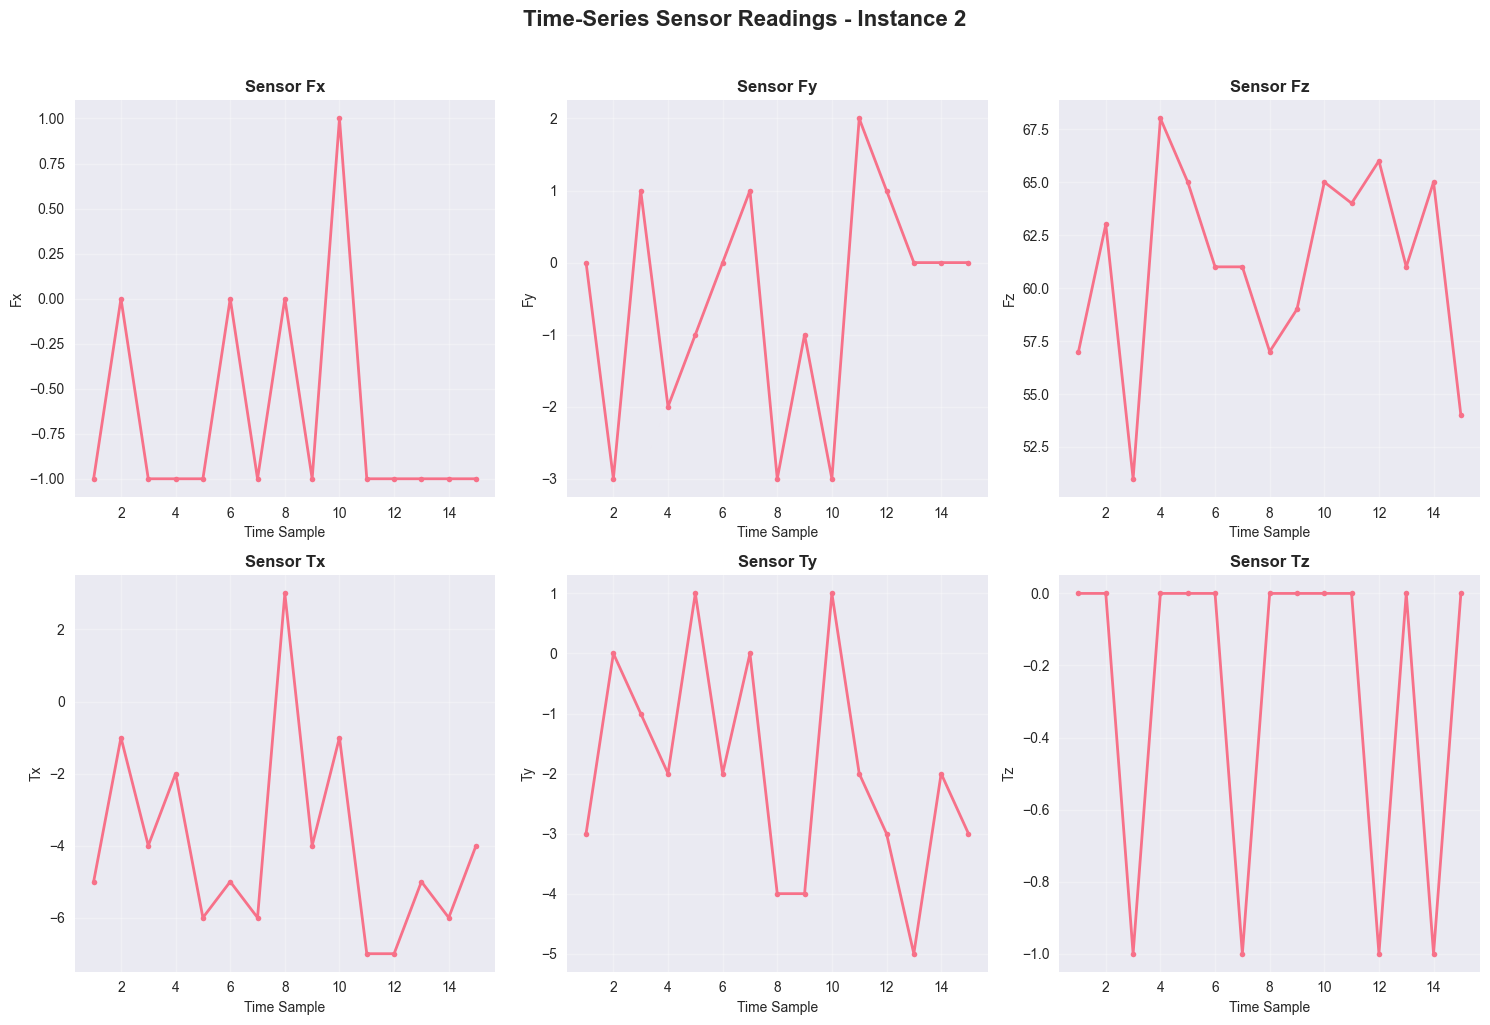


Instance 2:
  Label: normal
  Source: LP1

TIME-SERIES - ANOMALY INSTANCES
Anomalies typically show:
  - Sudden spikes (collisions)
  - Gradual increases (obstructions)
  - Oscillations (vibrations, mechanical issues)
  - Unusual patterns (tool failures)


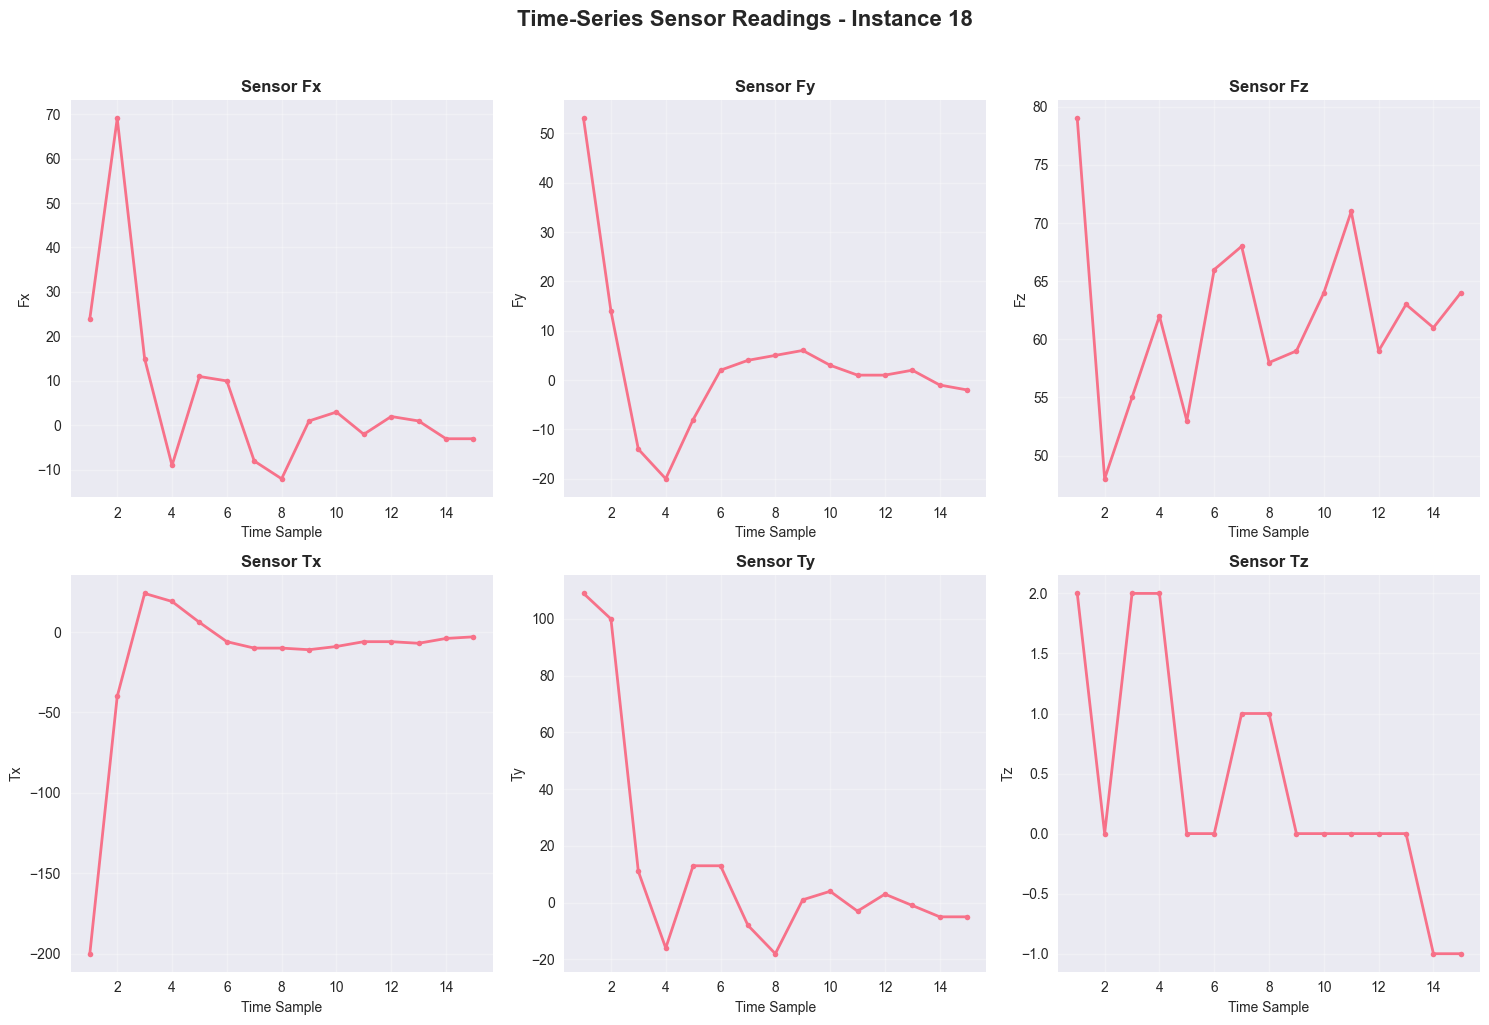


Instance 18:
  Label: collision
  Source: LP1


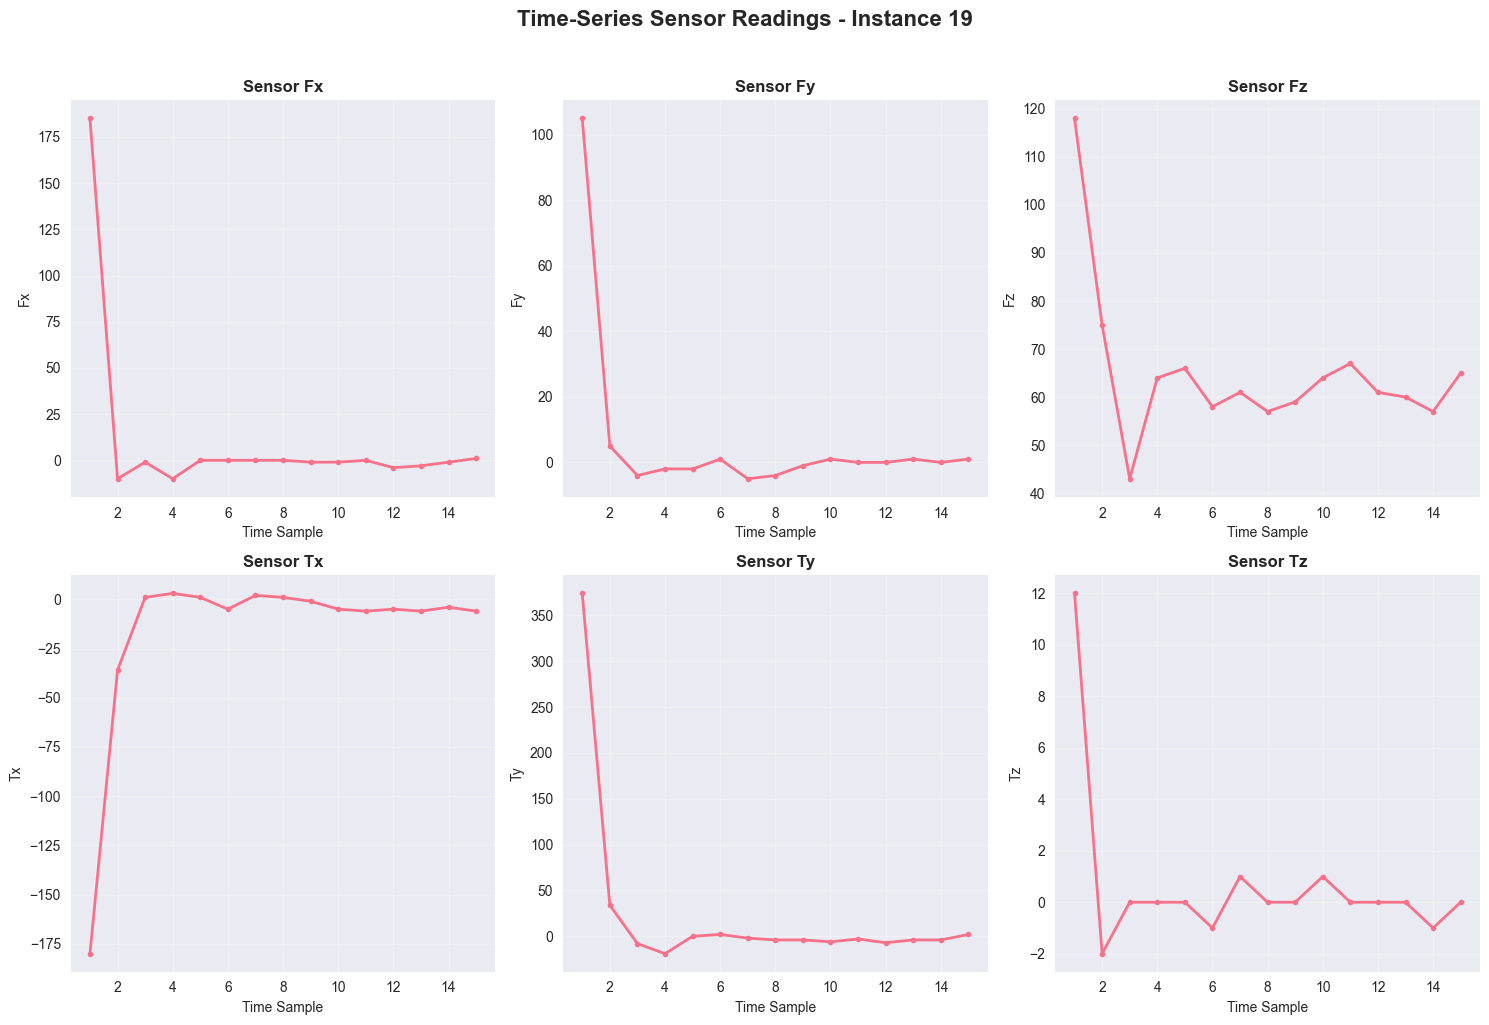


Instance 19:
  Label: collision
  Source: LP1


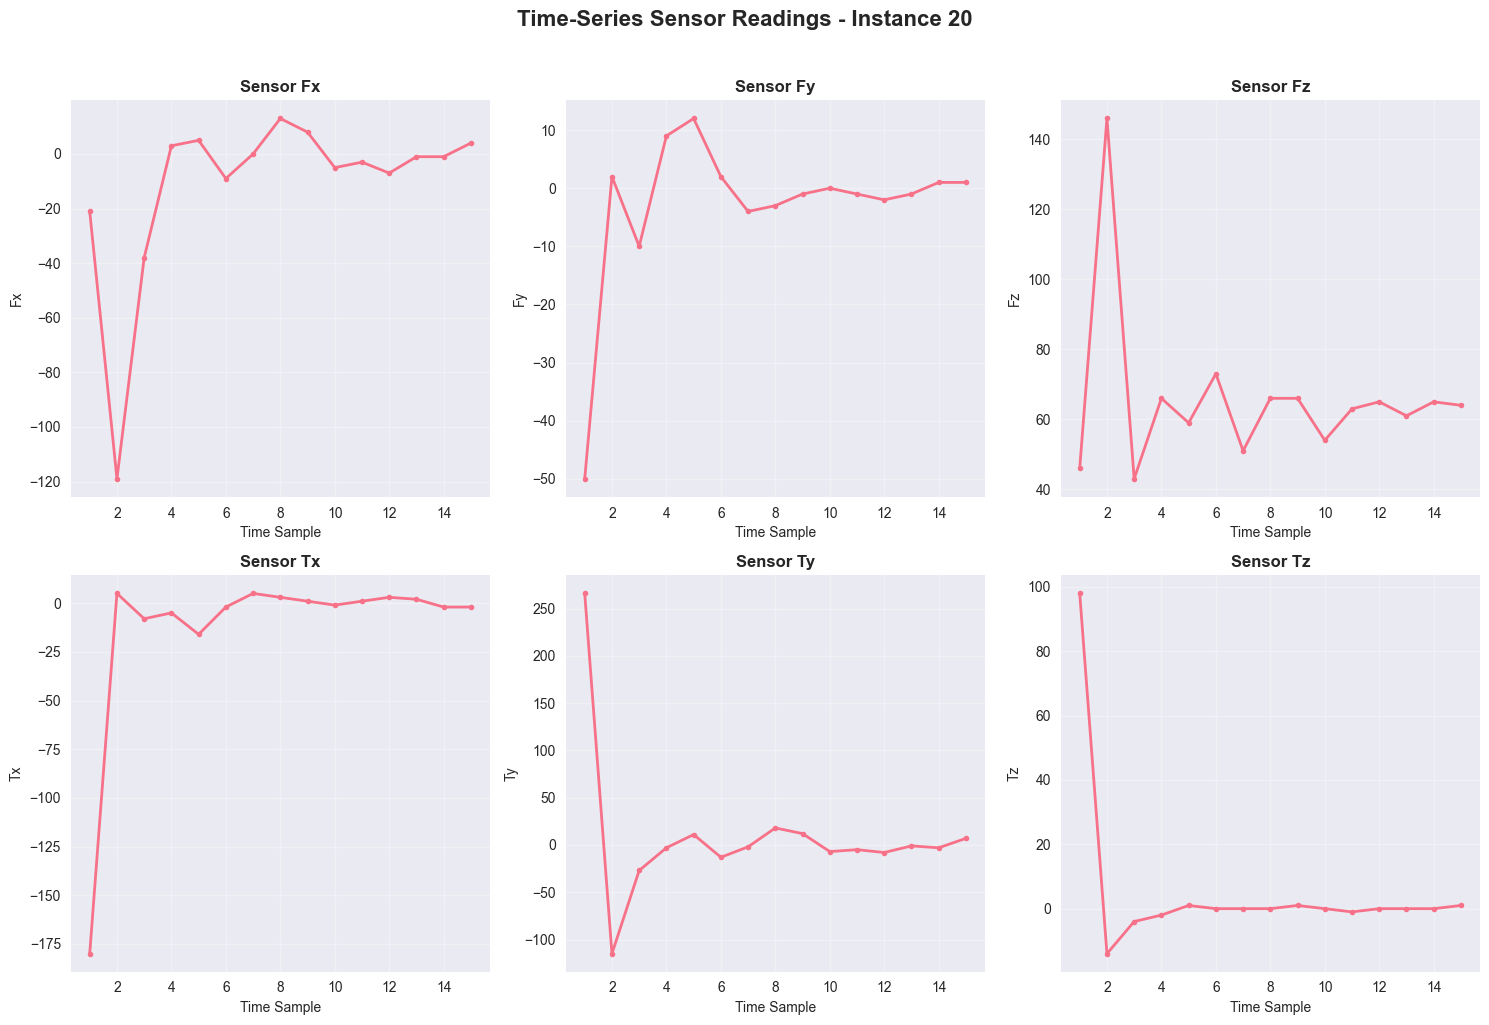


Instance 20:
  Label: collision
  Source: LP1


In [25]:
# Visualize time-series sensor readings for sample instances
# This helps understand temporal patterns in normal vs anomalous operations
print("Visualizing time-series sensor readings...")

# Select sample instances from each class
# we compare normal and anomaly patterns to understand differences
normal_instances = df[df['label_binary'] == 0].index[:3].tolist()
anomaly_instances = df[df['label_binary'] == 1].index[:3].tolist()

print(f"\nNormal instances (indices): {normal_instances}")
print(f"Anomaly instances (indices): {anomaly_instances}")

# Visualize normal instances
# Normal operations typically show smooth, predictable patterns
print("\n" + "="*60)
print("TIME-SERIES - NORMAL INSTANCES")
print("="*60)
print("Normal operations typically show:")
print("  - Smooth sensor readings")
print("  - Predictable patterns")
print("  - Low variability")
print("  - Consistent force/torque values")
for idx in normal_instances:
    plot_time_series(df, instance_idx=idx)

# Visualize anomaly instances
# Anomalies typically show sudden changes, spikes, or unusual patterns
print("\n" + "="*60)
print("TIME-SERIES - ANOMALY INSTANCES")
print("="*60)
print("Anomalies typically show:")
print("  - Sudden spikes (collisions)")
print("  - Gradual increases (obstructions)")
print("  - Oscillations (vibrations, mechanical issues)")
print("  - Unusual patterns (tool failures)")
for idx in anomaly_instances:
    plot_time_series(df, instance_idx=idx)



## 8. comparison of normal vs anomaly patterns

Reference: Lesson 1 - Comparative Analysis and Pattern Recognition

We compare average sensor patterns between normal and anomaly instances. This analysis helps identify which sensors and time periods are most indicative of anomalies, informing feature engineering strategies.

### Industrial interpretation

- Normal patterns: Smooth, predictable sensor readings indicating successful operations
- Anomaly patterns: Sudden changes, spikes, or unusual patterns indicating failures
- Differences: Magnitude and direction of differences help identify critical sensors

This comparative analysis provides insights for:
- Feature selection (which sensors are most informative)
- Feature engineering (which time periods show most differences)
- Model interpretation (understanding what anomalies "look like" in sensor data)



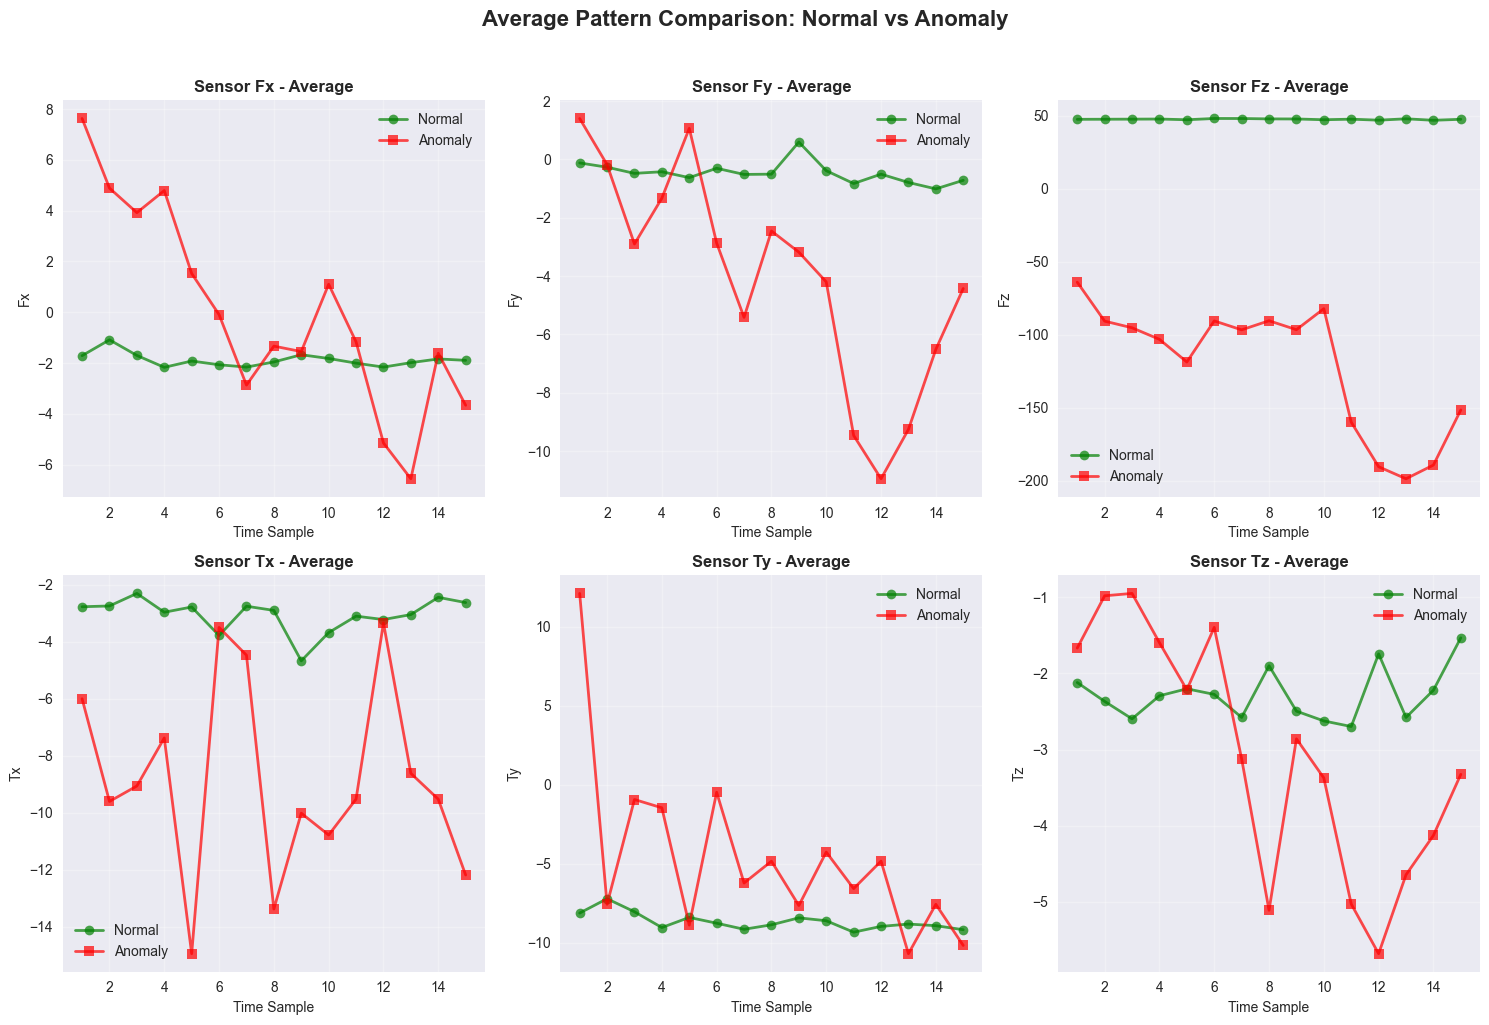


AVERAGE DIFFERENCES: Normal vs Anomaly

Mean absolute differences by sensor:
  Fx: 3.2041
  Fy: 4.0251
  Fz: 168.6557
  Tx: 5.8085
  Ty: 4.4880
  Tz: 1.4652
Most Informative Sensors (largest differences):
   Fz: 168.6557
   Tx: 5.8085
   Ty: 4.4880
Interpretation:
   - Sensors with larger differences are more indicative of anomalies
   - These sensors should be prioritized in feature engineering
   - Feature importance analysis (Lesson 3) will validate this


In [26]:
# Compare average patterns between normal and anomaly instances
# This helps identify which sensors and time periods show most differences
feature_cols = [col for col in df.columns if col.startswith('feature_')]
sensors = ['Fx', 'Fy', 'Fz', 'Tx', 'Ty', 'Tz']
samples_per_sensor = 15

# Separate normal and anomaly data
normal_data = df[df['label_binary'] == 0][feature_cols].values
anomaly_data = df[df['label_binary'] == 1][feature_cols].values

# Compute average patterns
if len(normal_data) > 0 and len(anomaly_data) > 0:
    normal_mean = normal_data.mean(axis=0)
    anomaly_mean = anomaly_data.mean(axis=0)
    
    # Reshape: 15 samples × 6 sensors
    if len(normal_mean) == samples_per_sensor * len(sensors):
        normal_mean_reshaped = normal_mean.reshape(samples_per_sensor, len(sensors))
        anomaly_mean_reshaped = anomaly_mean.reshape(samples_per_sensor, len(sensors))
        
        # Visualize comparison
        fig, axes = plt.subplots(2, 3, figsize=(15, 10))
        axes = axes.flatten()
        
        time_steps = np.arange(1, samples_per_sensor + 1)
        
        for i, sensor in enumerate(sensors):
            axes[i].plot(time_steps, normal_mean_reshaped[:, i], 
                        label='Normal', linewidth=2, marker='o', color='green', alpha=0.7)
            axes[i].plot(time_steps, anomaly_mean_reshaped[:, i], 
                        label='Anomaly', linewidth=2, marker='s', color='red', alpha=0.7)
            axes[i].set_xlabel('Time Sample', fontsize=10)
            axes[i].set_ylabel(f'{sensor}', fontsize=10)
            axes[i].set_title(f'Sensor {sensor} - Average', fontsize=12, fontweight='bold')
            axes[i].legend()
            axes[i].grid(alpha=0.3)
        
        plt.suptitle('Average Pattern Comparison: Normal vs Anomaly', 
                     fontsize=16, fontweight='bold', y=1.02)
        plt.tight_layout()
        plt.show()
        
        # Display differences
        print("\n" + "="*60)
        print("AVERAGE DIFFERENCES: Normal vs Anomaly")
        print("="*60)
        print("\nMean absolute differences by sensor:")
        sensor_differences = {}
        for i, sensor in enumerate(sensors):
            diff = np.mean(np.abs(normal_mean_reshaped[:, i] - anomaly_mean_reshaped[:, i]))
            sensor_differences[sensor] = diff
            print(f"  {sensor}: {diff:.4f}")
        
        # Identify sensors with largest differences (most informative)
        sorted_sensors = sorted(sensor_differences.items(), key=lambda x: x[1], reverse=True)
        print(f"Most Informative Sensors (largest differences):")
        for sensor, diff in sorted_sensors[:3]:
            print(f"   {sensor}: {diff:.4f}")
        print(f"Interpretation:")
        print(f"   - Sensors with larger differences are more indicative of anomalies")
        print(f"   - These sensors should be prioritized in feature engineering")
        print(f"   - Feature importance analysis (Lesson 3) will validate this")



## 9. anomaly type analysis

Reference: Lesson 1 - Multi-class Classification and Failure Mode Analysis

While we simplify the problem to binary classification (normal vs anomaly), understanding the original multi-class structure helps interpret model results and understand different failure modes.

### Failure types in industrial robotics

The dataset contains multiple failure types:
- Collisions: Sudden contact with obstacles or parts
- Obstructions: Gradual resistance to movement
- Tool failures: Malfunctions in robotic tools
- Positioning errors: Deviations from intended positions

### Industrial relevance

Different failure types may require different responses:
- Collisions: Immediate shutdown, safety protocols
- Obstructions: Slower operations, obstacle detection
- Tool failures: Tool replacement, maintenance scheduling
- Positioning errors: Recalibration, path planning adjustments

Academic Note: While we use binary classification for simplicity, future work could explore multi-class classification for more specific failure type identification.

Analysons les différents types d'anomalies présentes dans le dataset et leur distribution.



ANALYSE DES TYPES D'ANOMALIES

Types d'anomalies identifiés: ['collision' 'obstruction' 'fr_collision' 'back_col' 'front_col'
 'right_col' 'left_col' 'ok' 'moved' 'slightly_moved' 'lost'
 'collision_in_tool' 'collision_in_part' 'bottom_obstruction'
 'bottom_collision']

Distribution des types d'anomalies:
label
collision             89
obstruction           55
collision_in_part     47
collision_in_tool     26
bottom_collision      26
bottom_obstruction    21
ok                    20
fr_collision          16
moved                 15
left_col               9
slightly_moved         9
back_col               7
front_col              6
right_col              5
lost                   3
Name: count, dtype: int64


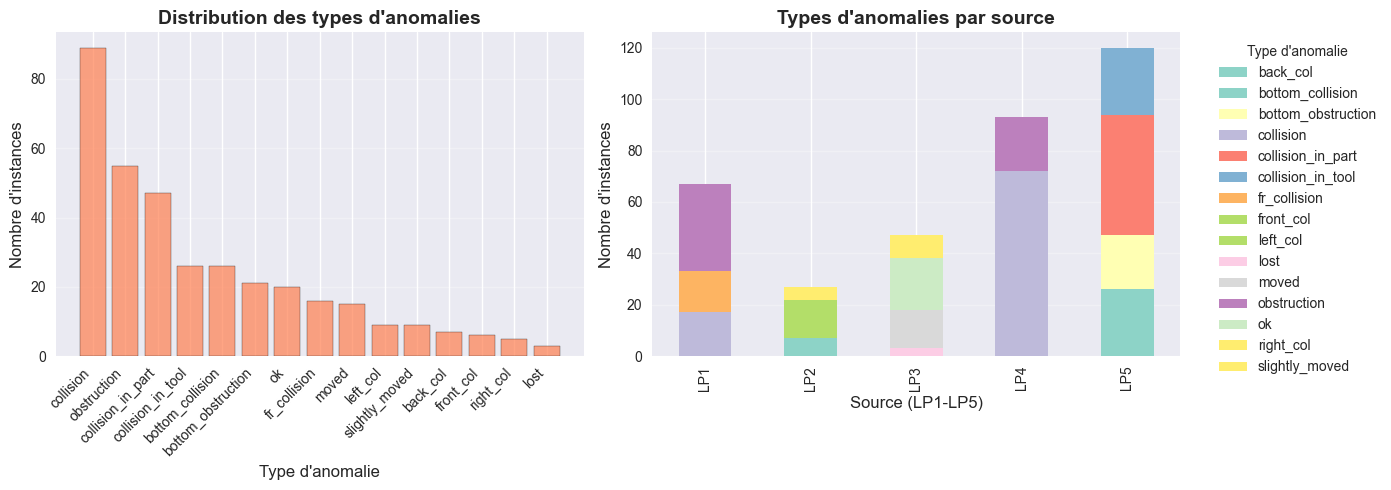

In [27]:
# Analyser the types d'anomalies
print("="*60)
print("ANALYSE DES TYPES D'ANOMALIES")
print("="*60)

# Types d'anomalies (all labels sauf 'normal')
anomaly_types = df[df['label_binary'] == 1]['label'].unique()
print(f"\nTypes d'anomalies identifiés: {anomaly_types}")

# Distribution des types d'anomalies
print("\nDistribution des types d'anomalies:")
anomaly_distribution = df[df['label_binary'] == 1]['label'].value_counts()
print(anomaly_distribution)

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution des types d'anomalies
axes[0].bar(range(len(anomaly_distribution)), anomaly_distribution.values, 
           color='coral', edgecolor='black', alpha=0.7)
axes[0].set_xticks(range(len(anomaly_distribution)))
axes[0].set_xticklabels(anomaly_distribution.index, rotation=45, ha='right')
axes[0].set_xlabel('Type d\'anomalie', fontsize=12)
axes[0].set_ylabel('Nombre d\'instances', fontsize=12)
axes[0].set_title('Distribution des types d\'anomalies', fontsize=14, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Distribution par source et type d'anomalie
if 'source' in df.columns:
    anomaly_source_dist = df[df['label_binary'] == 1].groupby(['source', 'label']).size().unstack(fill_value=0)
    anomaly_source_dist.plot(kind='bar', stacked=True, ax=axes[1], colormap='Set3')
    axes[1].set_xlabel('Source (LP1-LP5)', fontsize=12)
    axes[1].set_ylabel('Nombre d\'instances', fontsize=12)
    axes[1].set_title('Types d\'anomalies par source', fontsize=14, fontweight='bold')
    axes[1].legend(title='Type d\'anomalie', bbox_to_anchor=(1.05, 1), loc='upper left')
    axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()



## 10. Summary and key takeaways

Reference: Lesson 1 - Data Exploration Summary

This notebook covered the complete data exploration phase of the ML pipeline. Key findings and insights are summarized below.

### Main observations:

1. Data Structure: 90 features (15 time samples × 6 sensors) per instance
   - High dimensionality requires careful feature engineering
   - Time-series nature allows temporal pattern extraction

2. Class Distribution: Significant class imbalance (23.5% normal, 76.5% anomaly)
   - Requires careful evaluation metrics (F1-score, precision, recall)
   - May benefit from resampling techniques (SMOTE) or class weights

3. Data Sources: 5 robotic task types (LP1-LP5) with different anomaly distributions
   - Stratified analysis helps understand data heterogeneity
   - Informs cross-validation strategies (Lesson 4)

4. Sensors: 6 sensors measuring forces (Fx, Fy, Fz) and torques (Tx, Ty, Tz)
   - Physical interpretation helps feature engineering
   - Sensor differences indicate which sensors are most informative

5. Temporal Patterns: Time-series reveal differences between normal and anomaly instances
   - Normal: Smooth, predictable patterns
   - Anomalies: Sudden spikes, oscillations, unusual patterns

### Industrial insights:

- Collisions: Characterized by sudden force/torque spikes
- Obstructions: Characterized by constant high force/torque values
- Tool Failures: May cause oscillations or outliers in sensor readings

### Academic learning:

- Data Quality: Understanding data structure and quality is crucial for ML success
- Class Imbalance: Requires appropriate evaluation metrics and training strategies
- Feature Engineering: Time-series data requires specialized feature extraction
- Domain Knowledge: Understanding sensor physics informs feature engineering

### Next steps:

In the next notebook (02_Preprocessing_and_FeatureEngineering.ipynb), we will:
- Preprocess data: Handle missing values, normalize/standardize features
- Create statistical features: Extract mean, std, min, max, skew, kurtosis, trend
- Apply PCA: Reduce dimensionality while preserving variance
- Prepare data: Create train/test splits for model training

Reference: Lesson 2 - Data Preprocessing and Feature Engineering



In [28]:
print("="*60)
print("DATA EXPLORATION COMPLETE")
print("="*60)
print("\nDataset Summary:")
print(f"  - Total instances: {len(df)}")
print(f"  - Number of features: {len([col for col in df.columns if col.startswith('feature_')])}")
print(f"  - Number of classes (original): {len(df['label'].unique())}")
print(f"  - Number of sources: {len(df['source'].unique())}")
print(f"\nBinary Distribution:")
normal_count = len(df[df['label_binary'] == 0])
anomaly_count = len(df[df['label_binary'] == 1])
print(f"    Normal (0): {normal_count} ({normal_count/len(df)*100:.1f}%)")
print(f"    Anomaly (1): {anomaly_count} ({anomaly_count/len(df)*100:.1f}%)")
print(f"    Imbalance ratio: {anomaly_count/normal_count:.2f}:1")

print("Key Findings:")
print("  1. Significant class imbalance detected (76.5% anomalies)")
print("  2. High-dimensional data (90 features) requires feature engineering")
print("  3. Time-series patterns differ between normal and anomaly instances")
print("  4. Multiple failure types suggest complex anomaly detection problem")
print("  5. Sensor differences indicate potential for feature selection")

print("Next Steps:")
print("  → Proceed to Notebook 2: Preprocessing and Feature Engineering")
print("  → Apply data normalization and standardization")
print("  → Create statistical features from time-series data")
print("  → Apply PCA for dimensionality reduction")
print("  → Prepare data for model training")



DATA EXPLORATION COMPLETE

Dataset Summary:
  - Total instances: 463
  - Number of features: 90
  - Number of classes (original): 16
  - Number of sources: 5

Binary Distribution:
    Normal (0): 109 (23.5%)
    Anomaly (1): 354 (76.5%)
    Imbalance ratio: 3.25:1
Key Findings:
  1. Significant class imbalance detected (76.5% anomalies)
  2. High-dimensional data (90 features) requires feature engineering
  3. Time-series patterns differ between normal and anomaly instances
  4. Multiple failure types suggest complex anomaly detection problem
  5. Sensor differences indicate potential for feature selection
Next Steps:
  → Proceed to Notebook 2: Preprocessing and Feature Engineering
  → Apply data normalization and standardization
  → Create statistical features from time-series data
  → Apply PCA for dimensionality reduction
  → Prepare data for model training
